<a href="https://colab.research.google.com/github/Shiyasalloor/Image_and_Video_processing_lab/blob/main/Set_3_Question_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import imageio

In [5]:
def rgb_to_hsi(rgb_img):
    rgb = rgb_img.astype(np.float32) / 255.0
    R, G, B = rgb[..., 0], rgb[..., 1], rgb[..., 2]

    # Intensity
    I = (R + G + B) / 3.0

    # Saturation
    min_val = np.minimum(np.minimum(R, G), B)
    S = 1 - (3 / (R + G + B + 1e-6)) * min_val  # avoid div/0

    # Hue calculation
    num = 0.5 * ((R - G) + (R - B))
    den = np.sqrt((R - G)**2 + (R - B) * (G - B)) + 1e-6
    theta = np.arccos(num / den)

    H = np.zeros_like(R)
    H[B <= G] = theta[B <= G]
    H[B > G] = 2 * np.pi - theta[B > G]
    H = H / (2 * np.pi)  # normalize to [0,1]

    return H, S, I

In [7]:
def main():
    try:
        rgb_img = imageio.imread("/content/dog.png")
    except FileNotFoundError:
        from scipy import misc
        rgb_img = misc.face()

    H, S, I = rgb_to_hsi(rgb_img)

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 4, 1)
    plt.imshow(rgb_img)
    plt.title("Original RGB")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(H, cmap="hsv")
    plt.title("Hue")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(S, cmap="gray")
    plt.title("Saturation")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(I, cmap="gray")
    plt.title("Intensity")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

/tmp/ipython-input-1696340327.py:3: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  rgb_img = imageio.imread("/content/dog.png")


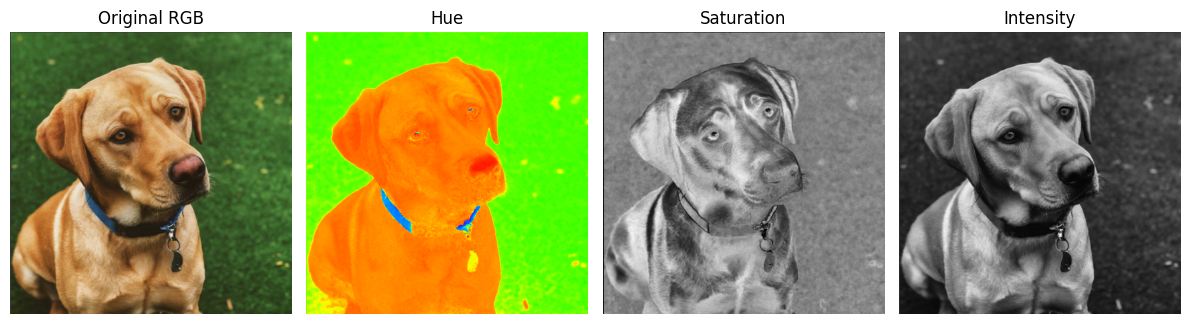

In [8]:
if __name__ == "__main__":
    main()